In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns   
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def wrangle_meter_data(df):
    """
    Prepare meter data for classification model training.
    
    Args:
        df (pd.DataFrame): Raw meter data.
        scale_features (bool): Whether to scale numeric features.
        
    Returns:
        X (pd.DataFrame or np.array): Feature matrix ready for training.
        y (pd.Series): Target variable IsAtRisk.
    """

    # If DSR_percent is less than 85, 'IsAtRisk' will be 1 (True), otherwise it will be 0 (False).
    df['IsAtRisk'] = (df['DSR_percent'] < 85).astype(int)
    
    # Drop columns that can leak the target
    drop_cols = ['MeterID', 'Latitude', 'Longitude', 'ExpectedReads', 'ActualReads', 'DSR_percent']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])
    
    if 'LidType' in df.columns:
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded = encoder.fit_transform(df[['LidType']])
        df[[*encoder.get_feature_names_out(['LidType'])]] = encoded
        df = df.drop('LidType', axis=1)
    
    
    # Separate target
    y = df['IsAtRisk']
    X = df.drop(columns=['IsAtRisk'])
    
    return X, y

# -----------------------------
# Load Excel file
# -----------------------------
df = pd.read_excel("C:/Users/hp/Documents/Netmore Task/data/Raw Data set.xlsx")
# Create the 'IsAtRisk' column based on the DSR_percent


# Prepare data for modeling
X, y = wrangle_meter_data(df)



# Check the processed data
print(X.head())
print(y.head())


   RSSI_dBm  SNR_dB  SpreadingFactor  Depth_mm  \
0     -84.9    10.9               11       450   
1     -84.2    11.6                9       450   
2     -81.9    12.8                8       450   
3     -83.5    14.5                8       400   
4     -82.4     9.0                9       800   

   DistanceToNearestGateway (meters)  LidType_Composite  LidType_Plastic  
0                                147                1.0              0.0  
1                                 95                0.0              1.0  
2                                 63                1.0              0.0  
3                                 78                0.0              1.0  
4                                 76                0.0              1.0  
0    0
1    0
2    0
3    0
4    0
Name: IsAtRisk, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# X, y are the wrangled features and target from your training dataset

# Split into train and validation (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class distribution consistent
)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Training class distribution:\n", y_train.value_counts(normalize=True))
print("Validation class distribution:\n", y_val.value_counts(normalize=True))


df_test = pd.read_excel("C:/Users/hp/Documents/Netmore Task/data/Test Data.xlsx")
# Create the 'IsAtRisk' column based on the DSR_percent
# If DSR_percent is less than 85, 'IsAtRisk' will be 1 (True), otherwise it will be 0 (False).
df_test['IsAtRisk'] = (df_test['DSR_percent'] < 85).astype(int)
# Prepare data for modeling
X_test, y_test = wrangle_meter_data(df_test)

y_test.head()
X_test.head()
y_test.value_counts()

X_test = X_test[X_train.columns]


Training set shape: (4000, 7)
Validation set shape: (1000, 7)
Training class distribution:
 IsAtRisk
1    0.888
0    0.112
Name: proportion, dtype: float64
Validation class distribution:
 IsAtRisk
1    0.888
0    0.112
Name: proportion, dtype: float64


In [5]:
import os
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

# ============================================================
# 1️⃣ Build XGBoost Pipeline
# ============================================================
pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),  # Optional for consistency; XGBoost handles unscaled data too
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        #use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=None,  # can set to ratio of negatives/positives if needed
    ))
])

# ============================================================
# 2️⃣ Define Parameter Grid for GridSearchCV
# ============================================================
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
}

# ============================================================
# 3️⃣ Stratified 5-Fold Cross Validation
# ============================================================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 4️⃣ GridSearchCV — optimize for recall (don’t miss at-risk meters)
# ============================================================
grid_search = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    scoring='recall',
    cv=kfold,
    n_jobs=-1,
    verbose=2
)

# ============================================================
# 5️⃣ Train Model (on imbalanced data, no oversampling)
# ============================================================
grid_search.fit(X_train, y_train)

print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)
print(f"Best CV Recall Score: {grid_search.best_score_:.4f}")

# Get best estimator
best_xgb_model = grid_search.best_estimator_

# ============================================================
# 6️⃣ Cross-Validation Metrics (using best model)
# ============================================================
scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(best_xgb_model, X_train, y_train, cv=kfold, scoring=scoring)

print("\n=== Cross-Validation Performance (Best Model) ===")
for metric in scoring:
    print(f"{metric.capitalize():<10}: {cv_results['test_' + metric].mean():.4f} ± {cv_results['test_' + metric].std():.4f}")

# ============================================================
# 7️⃣ Fit Best Model on Full Training Data
# ============================================================
best_xgb_model.fit(X_train, y_train)

# ============================================================
# 8️⃣ Save Model
# ============================================================
save_path = r"C:\Users\hp\Documents\Netmore Task\src\xgboost_best_pipeline.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(best_xgb_model, save_path)

print(f"\n✅ XGBoost (optimized, imbalanced data) trained and saved successfully at:\n{save_path}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Best Parameters Found ===
{'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best CV Recall Score: 0.9837

=== Cross-Validation Performance (Best Model) ===
Accuracy  : 0.9715 ± 0.0046
Precision : 0.9848 ± 0.0048
Recall    : 0.9831 ± 0.0024
F1        : 0.9839 ± 0.0026

✅ XGBoost (optimized, imbalanced data) trained and saved successfully at:
C:\Users\hp\Documents\Netmore Task\src\xgboost_best_pipeline.pkl


In [6]:
# ============================================================
# 9️⃣ Evaluate on Test Data (Default Threshold = 0.5)
# ============================================================
print("\n=== XGBoost Test Evaluation (Threshold = 0.5) ===")
y_pred = best_xgb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print(f"Precision (At-Risk): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (At-Risk):    {recall_score(y_test, y_pred):.4f}")




=== XGBoost Test Evaluation (Threshold = 0.5) ===
Confusion Matrix:
 [[  2   8]
 [  2 188]]

Classification Report:
               precision    recall  f1-score   support

           0     0.5000    0.2000    0.2857        10
           1     0.9592    0.9895    0.9741       190

    accuracy                         0.9500       200
   macro avg     0.7296    0.5947    0.6299       200
weighted avg     0.9362    0.9500    0.9397       200

Precision (At-Risk): 0.9592
Recall (At-Risk):    0.9895


In [7]:
# ============================================================
# 🔟 Recall-Focused Evaluation (Lower Threshold)
# ============================================================
y_proba = best_xgb_model.predict_proba(X_test)[:, 1]
threshold = 0.40  # Adjust threshold for recall priority
y_pred_recall_focus = (y_proba >= threshold).astype(int)

print("\n=== XGBoost Recall-Focused Evaluation (Threshold = 0.35) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_recall_focus))
print("\nClassification Report:\n", classification_report(y_test, y_pred_recall_focus, digits=4))
print(f"Precision (At-Risk): {precision_score(y_test, y_pred_recall_focus):.4f}")
print(f"Recall (At-Risk):    {recall_score(y_test, y_pred_recall_focus):.4f}")


=== XGBoost Recall-Focused Evaluation (Threshold = 0.35) ===
Confusion Matrix:
 [[  2   8]
 [  2 188]]

Classification Report:
               precision    recall  f1-score   support

           0     0.5000    0.2000    0.2857        10
           1     0.9592    0.9895    0.9741       190

    accuracy                         0.9500       200
   macro avg     0.7296    0.5947    0.6299       200
weighted avg     0.9362    0.9500    0.9397       200

Precision (At-Risk): 0.9592
Recall (At-Risk):    0.9895


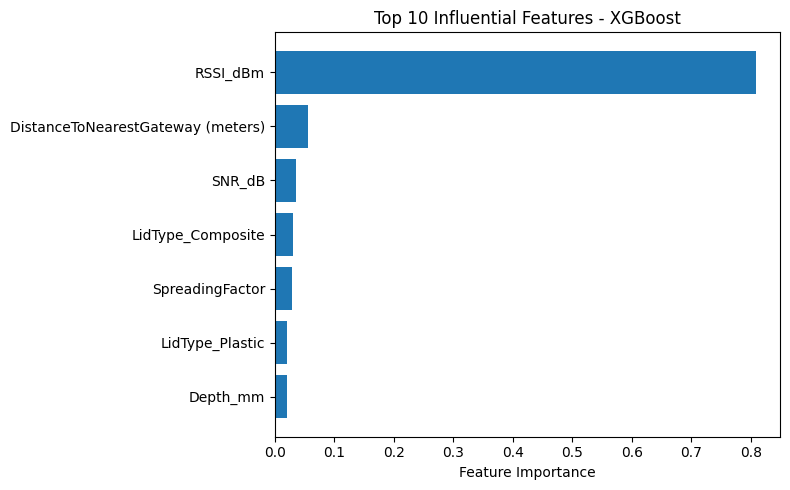

In [8]:
# === Load trained XGBoost model ===
xgb_model_path = r"C:\Users\hp\Documents\Netmore Task\src\xgboost_best_pipeline.pkl"
pipeline_xgb = joblib.load(xgb_model_path)

# === Extract feature importances ===
feature_names = X_train.columns
importances = pipeline_xgb.named_steps['clf'].feature_importances_

xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# === Plot top 10 features ===
plt.figure(figsize=(8, 5))
plt.barh(xgb_importance['Feature'][:10][::-1], xgb_importance['Importance'][:10][::-1])
plt.title("Top 10 Influential Features - XGBoost")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()
